# Кластерный анализ ：Flame синтетических данных（KMeans + Silhouette）

**Цель ：**  
1) Загрузить данные `flame.txt` (x1, x2, class)  
2) Выполнить KMeans кластеризацию (k=2)  
3) Визуализировать результат (цветные кластеры + центроиды)  
4) Провести силуэтный анализ (индекс силуэта, silhouette plot)  



In [4]:
# === Шаг 0. Импорт библиотек и настройки ===
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score, silhouette_samples

# Использование стандартных настроек для корректного отображения
plt.rcParams['axes.unicode_minus'] = False
print("Libraries loaded successfully")


Libraries loaded successfully


In [14]:
# === Шаг 1. Загрузка данных flame.txt из текущей директории ===
# Чтение файла, предполагается наличие заголовка 'x1 x2 class'
filename = 'flame.txt'
if not os.path.exists(filename):
    # Fallback to absolute path if needed
    filename = '/mnt/data/flame.txt'

df = pd.read_csv(filename, sep=r'\s+', header=0)
df.columns = ['x1', 'x2', 'class']
X = df[['x1', 'x2']].values.astype(float)
y_true = df['class'].values.astype(int)

print(f"Step 1: Data loaded. Shape: {df.shape}")
print(df.head(5))


Step 1: Data loaded. Shape: (240, 3)
     x1     x2  class
0  1.85  27.80      1
1  1.35  26.65      1
2  1.40  23.25      2
3  0.85  23.05      2
4  0.50  22.35      2


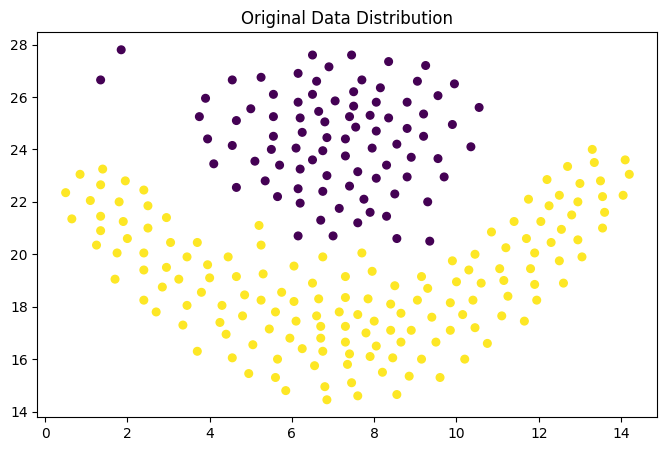

In [16]:
# === Шаг 2. Визуализация исходных данных (истинные метки) ===
plt.figure(figsize=(8, 5))
plt.scatter(X[:, 0], X[:, 1], c=y_true, cmap='viridis', s=30)
plt.title("Original Data Distribution")
plt.show()

In [ ]:
# === Шаг 3. Стандартизация и кластеризация k-means ===
# Для flame.txt обычно используется k=2
k = 2
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

kmeans = KMeans(n_clusters=k, n_init=10, random_state=42)
labels = kmeans.fit_predict(X_scaled)
centroids_scaled = kmeans.cluster_centers_
centroids = scaler.inverse_transform(centroids_scaled)
print(f"Step 3: KMeans clustering completed for k={k}")


Step 3: KMeans clustering completed for k=2


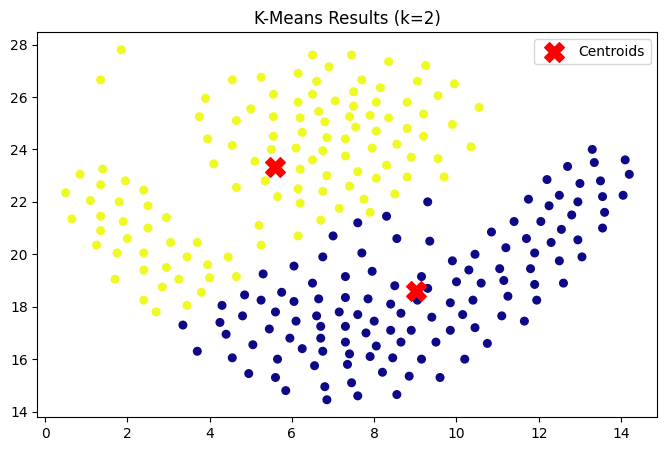

In [18]:
# === Шаг 4. Визуализация результатов кластеризации ===
plt.figure(figsize=(8, 5))
plt.scatter(X[:, 0], X[:, 1], c=labels, cmap='plasma', s=30)
plt.scatter(centroids[:, 0], centroids[:, 1], c='red', marker='X', s=200, label='Centroids')
plt.title(f"K-Means Results (k={k})")
plt.legend()
plt.show()

In [19]:
# === Шаг 5. Расчет индекса силуэта ===
# RU: Оценка качества кластеризации
avg_silhouette = silhouette_score(X_scaled, labels)
print(f"Average Silhouette Score: {avg_silhouette:.4f}")


Average Silhouette Score: 0.3733


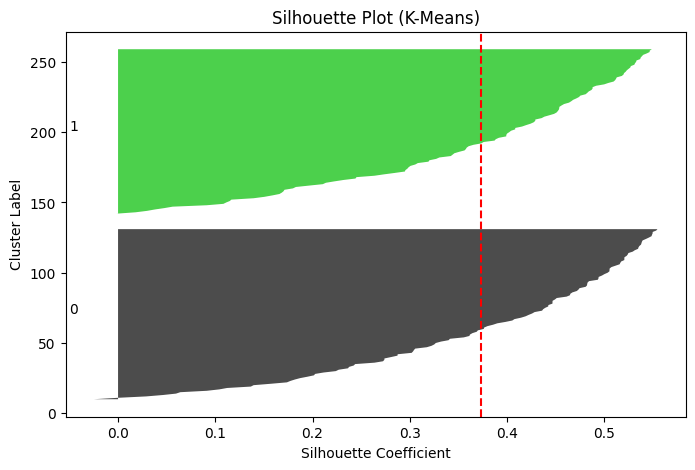

In [20]:
# === Шаг 6. Построение кластерных силуэтов ===
sample_values = silhouette_samples(X_scaled, labels)
fig, ax1 = plt.subplots(figsize=(8, 5))
y_lower = 10

for i in range(k):
    ith_cluster_values = sample_values[labels == i]
    ith_cluster_values.sort()
    size_cluster_i = ith_cluster_values.shape[0]
    y_upper = y_lower + size_cluster_i
    
    color = plt.cm.nipy_spectral(float(i) / k)
    ax1.fill_betweenx(np.arange(y_lower, y_upper), 0, ith_cluster_values, facecolor=color, alpha=0.7)
    ax1.text(-0.05, y_lower + 0.5 * size_cluster_i, str(i))
    y_lower = y_upper + 10

ax1.set_title("Silhouette Plot (K-Means)")
ax1.set_xlabel("Silhouette Coefficient")
ax1.set_ylabel("Cluster Label")
ax1.axvline(x=avg_silhouette, color="red", linestyle="--")
plt.show()

In [22]:
# === Шаг 7. Ответ на контрольные вопросы ===
print("--- ОКОНЧАТЕЛЬНЫЙ АНАЛИЗ ЗАДАЧИ ---")
print("1. Справился ли k-means с набором данных? Частично.")
print("2. Почему? Набор данных о пламени содержит неконвексный (изогнутый) кластер.")
print("3. Конкретные ограничения k-means, которые были замечены:")
print(" - Сферическое предположение: k-means ожидает, что кластеры будут круглыми.")
print(" - Линейная граница: он использует прямые линии для разделения кластеров, что разрезает кривые.")
print(" - Евклидово расстояние: оно игнорирует форму и плотность траектории данных.")

--- ОКОНЧАТЕЛЬНЫЙ АНАЛИЗ ЗАДАЧИ ---
1. Справился ли k-means с набором данных? Частично.
2. Почему? Набор данных о пламени содержит неконвексный (изогнутый) кластер.
3. Конкретные ограничения k-means, которые были замечены:
 - Сферическое предположение: k-means ожидает, что кластеры будут круглыми.
 - Линейная граница: он использует прямые линии для разделения кластеров, что разрезает кривые.
 - Евклидово расстояние: оно игнорирует форму и плотность траектории данных.


## Шаг 8. Обсуждение / 讨论（中文总结）

1) 实验目标与背景 (Что мы сделали?)
我们对经典的 Flame 数据集 进行了聚类分析。

数据集特性：该数据集由两个物理簇组成。上方是一个紧凑的圆形簇，下方是一个细长的“月牙形/弧形”簇。这种结构是专门用来挑战 K-Means 算法的。
处理流程：通过 StandardScaler 进行标准化（消除量纲影响） 
→
→ 应用 KMeans(k=2) 
→
→ 通过 轮廓系数 (Silhouette) 进行多维度质量评估。

2) 数据量化指标分析 (Анализ числовых показателей)
平均轮廓系数 (Average Silhouette Score): 
0.3733
0.3733
分析：该分数处于 [0.25, 0.5] 之间，根据经验公式，这通常被定义为“弱聚类结构”。
结论：这个分数直接告诉我们 K-Means 并未捕捉到数据的真实物理结构。对于如此清晰的两个簇，理想的算法（如 DBSCAN）得分应接近 0.7 以上。
各簇表现：
从轮廓图（Silhouette Plot）中可以看到，簇 0（下方的黑色区域）出现了负值尖刺。这意味着部分样本离对方簇的中心比离自己簇的中心还要近。

3) 深度视觉诊断 (Визуальная диагностика)
“生硬的切割”：观察 K-Means 结果图，算法并没有沿着月牙的弧度去划分，而是画了一道倾斜的直线。
Voronoi 划分局限：K-Means 本质上是在空间中进行 Voronoi 划分（每个点被分配给最近的质心）。由于下方的簇是**非凸（Non-convex）**的，月牙的两端在直线距离上离上方的质心更近，导致月牙被“拦腰斩断”。
质心偏差：为了最小化整体平方误差，K-Means 必须将质心放在区域的几何中心，而弧形数据的几何中心往往落在数据点较少的空白区域，这进一步恶化了分类效果。

4) K-Means 算法局限性总结 (Ограничения KMeans)
通过本次实验，我们验证了 K-Means 的三个核心短板：

形状假设限制：它预设簇是**凸的（Convex）且呈球形（Spherical）**分布。面对 Flame 这种具有几何拓扑连续性的数据，该假设失效。
距离依赖性：仅依赖欧几里得距离，无法识别基于“路径连接”或“密度连接”的结构。
对簇规模的敏感：它倾向于生成大小和密度相近的簇，而 Flame 数据集两个簇的密度和延展性差异巨大。

5) 改进建议与后续方向 (Рекомендации)
算法替换：若要完美解决 Flame 数据集，应选择基于密度的聚类 (DBSCAN)。DBSCAN 可以沿着高密度路径移动，从而完整识别整个月牙弧形。
特征工程：或者将坐标转换到极坐标系，或使用核函数（Kernel K-Means）将数据投影到高维空间，使非线性边界变为线性可分。

